# Packing and a Small Mutation Scan

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/kdidi/sphinx-docs/docs/tutorial/04_packing_and_mutation_scan.ipynb)

This tutorial performs fixed-sequence side-chain repacking on a ten-residue ubiquitin slice, inspects the generated rotamer ensembles, batches a small mutation scan, and finishes with a two-position regional design. The examples use clearly marked helpers built from inspected `PackerTask` mask fields—TMol does not provide built-in mutation-scan, resfile, or FastDesign protocols.

> **Prerequisite.** Read [Scoring and Analysis](03_scoring_and_analysis.ipynb) first. The target-interaction value below uses its two-orientation block-pair accounting.

## Goals

- Configure `PackerPalette`, `PackerTask`, and the supported conformer samplers.
- Restrict repacking to a selected region while preserving sequence.
- Compare standard and expanded chi candidate counts and geometries.
- Evaluate several requested mutations together in one `PoseStack`.
- Run a small multi-position, multi-identity regional design batch.
- Separate an energy proxy from a physical folding or binding $\Delta\Delta G$.

> **GPU optional.** The small example runs on CPU; batching and larger design spaces benefit from CUDA.

## Setup

The setup uses the exact sampler construction exercised by TMol's packer tests and existing score/pack/minimize tutorial. The ten-residue slice keeps CPU execution practical.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "kdidi/sphinx-docs/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol import beta2016_score_function
from tmol.database import ParameterDatabase
from tmol.io.pose_stack_from_biotite import pose_stack_from_biotite
from tmol.numeric.dihedrals import coord_dihedrals
from tmol.pack.pack_rotamers import pack_rotamers
from tmol.pack.packer_task import PackerPalette, PackerTask, SetPackerTask
from tmol.pack.rotamer.build_rotamers import build_rotamers
from tmol.pack.rotamer.dunbrack.dunbrack_chi_sampler import (
    create_dunbrack_sampler_from_database,
)
from tmol.pack.rotamer.fixed_aa_chi_sampler import FixedAAChiSampler
from tmol.pack.rotamer.include_current_sampler import IncludeCurrentSampler
from tmol.pose.pose_stack_builder import PoseStackBuilder
from tmol.score.score_utils import build_sidechain_coord_mask, res_mask_to_coord_mask

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol/tests/data/cif/1UBQ.cif"

param_db = ParameterDatabase.get_default()
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 10)]
pose_stack = pose_stack_from_biotite(
    protein_slice, device, param_db=param_db, no_optH=True
)
score_function = beta2016_score_function(device, param_db=param_db)


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        display(frame)
        return None
    return show(frame)


def total_score(pose):
    scorer = score_function.render_whole_pose_scoring_module(pose)
    return float(scorer(pose.coords).detach().cpu()[0])

print(f"device={device}; input={cif_path.name}; slice blocks={pose_stack.max_n_blocks}")

device=cpu; input=1UBQ.cif; slice blocks=10


## Fixed-sequence regional repacking

`PackerPalette` defines the residue-type space considered from each starting block. `PackerTask.restrict_to_repacking()` keeps each position's `name3` fixed. The task then uses Dunbrack rotamers, fixed-amino-acid chi samples, and the current conformation.

Here residues 3–8 (zero-based block indices 2–7) are allowed to repack. `disable_packing_by_block_mask()` receives `True` where packing should be disabled.

In [3]:
palette = PackerPalette()
repack_task = PackerTask(pose_stack, palette)
repack_task.restrict_to_repacking()

packing_region = torch.zeros(
    (pose_stack.n_poses, pose_stack.max_n_blocks),
    dtype=torch.bool,
    device=device,
)
packing_region[:, 2:8] = True
repack_task.disable_packing_by_block_mask(~packing_region)
repack_task.add_conformer_sampler(
    create_dunbrack_sampler_from_database(param_db, device)
)
repack_task.add_conformer_sampler(FixedAAChiSampler())
repack_task.add_conformer_sampler(IncludeCurrentSampler())

start_score = total_score(pose_stack)
torch.manual_seed(SEED)
repacked_pose = pack_rotamers(pose_stack, score_function, repack_task)
repacked_score = total_score(repacked_pose)

packing_atom_mask = res_mask_to_coord_mask(pose_stack, packing_region)
packing_sidechain_mask = packing_atom_mask & build_sidechain_coord_mask(pose_stack)
sidechain_displacement = torch.linalg.vector_norm(
    repacked_pose.coords - pose_stack.coords, dim=-1
)[packing_sidechain_mask]
sidechain_rms_displacement = float(
    torch.sqrt(torch.mean(sidechain_displacement.square())).detach().cpu()
)
max_sidechain_displacement = float(sidechain_displacement.max().detach().cpu())
changed_sidechain_atoms = int((sidechain_displacement > 1e-3).sum().detach().cpu())

repack_frame = pd.DataFrame(
    [
        {
            "stage": "input",
            "beta2016": start_score,
            "score_change": 0.0,
            "packed_sidechain_RMS_displacement_A": 0.0,
            "max_sidechain_displacement_A": 0.0,
            "changed_sidechain_atoms": 0,
        },
        {
            "stage": "regional repack",
            "beta2016": repacked_score,
            "score_change": repacked_score - start_score,
            "packed_sidechain_RMS_displacement_A": sidechain_rms_displacement,
            "max_sidechain_displacement_A": max_sidechain_displacement,
            "changed_sidechain_atoms": changed_sidechain_atoms,
        },
    ]
)
show_table(repack_frame)

/home/runner/work/tmol/tmol/tmol/score/score_function.py:411: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  return torch.sparse_coo_tensor(


**Expected observations.** The amino-acid sequence is unchanged, only blocks 3–8 are allowed to choose side-chain conformers, and the score often decreases after repacking. The interactive table quantifies score change, RMS and maximum displacement over packed side-chain atoms, and how many moved more than 0.001 Å. Backbone movement should remain zero because the packer chooses discrete side-chain conformers rather than minimizing coordinates. Simulated annealing is stochastic, so fixed seeds make the tutorial reproducible without promising one exact energy.

The viewer is interactive when the parent documentation environment provides `py3Dmol`.

In [4]:
try:
    display(
        tmol.switchable_view(
            {"input": pose_stack, "regional repack": repacked_pose},
            notes={
                "input": f"weighted score: {start_score:.3f}",
                "regional repack": (
                    f"score {repacked_score:.3f}; Δ {repacked_score - start_score:+.3f}; "
                    f"side-chain RMS motion {sidechain_rms_displacement:.3f} Å"
                ),
            },
            width=720,
            height=420,
        )
    )
except ImportError as exc:
    print("Interactive repacking comparison unavailable:", exc)

## Expand side-chain sampling

TMol's `PackerTask.or_expand_chi()` requests additional samples at approximately ±1 standard deviation around supported chi wells. Extra sampling enlarges the search rather than guaranteeing a lower score: the stochastic annealer still has finite effort, and `IncludeCurrentSampler` keeps the input conformation available.

In [5]:
expanded_task = PackerTask(pose_stack, palette)
expanded_task.restrict_to_repacking()
expanded_task.disable_packing_by_block_mask(~packing_region)
expanded_task.add_conformer_sampler(
    create_dunbrack_sampler_from_database(param_db, device)
)
expanded_task.add_conformer_sampler(FixedAAChiSampler())
expanded_task.add_conformer_sampler(IncludeCurrentSampler())
expanded_task.or_expand_chi(1)
expanded_task.or_expand_chi(2)

torch.manual_seed(SEED)
expanded_repacked_pose = pack_rotamers(
    pose_stack, score_function, expanded_task
)
expanded_score = total_score(expanded_repacked_pose)
sampling_frame = pd.DataFrame(
    [
        {"sampling": "standard", "weighted_score": repacked_score},
        {"sampling": "expanded chi1 + chi2", "weighted_score": expanded_score},
    ]
)
show_table(sampling_frame)
display(
    tmol.switchable_view(
        {
            "standard rotamers": repacked_pose,
            "expanded chi1 + chi2": expanded_repacked_pose,
        },
        notes={
            "standard rotamers": f"score {repacked_score:.3f}",
            "expanded chi1 + chi2": f"score {expanded_score:.3f}",
        },
    )
)

## Inspect the generated rotamer ensembles

Expanded chi sampling changes the discrete search space before annealing. The table below builds both rotamer sets explicitly, reports candidate counts at each packed position, and measures named side-chain torsions for one representative block. This mirrors the conceptual emphasis of PyRosetta 6.1 while preserving TMol's tensor-oriented API.

The displayed torsions are candidate geometry, not a trajectory: simulated annealing evaluates many assignments and returns only the selected final conformation.

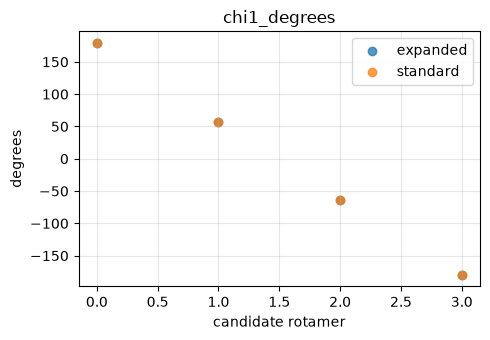

In [6]:
standard_rotamer_pose, standard_rotamers = build_rotamers(
    pose_stack,
    SetPackerTask.from_packer_task(repack_task),
    pose_stack.packed_block_types.chem_db,
)
expanded_rotamer_pose, expanded_rotamers = build_rotamers(
    pose_stack,
    SetPackerTask.from_packer_task(expanded_task),
    pose_stack.packed_block_types.chem_db,
)

rotamer_count_rows = []
for block_index in range(2, 8):
    block_type = pose_stack.block_type(0, block_index)
    rotamer_count_rows.append(
        {
            "block_index": block_index,
            "residue": block_type.name3,
            "standard_candidates": int(
                standard_rotamers.n_rots_for_block[0, block_index]
            ),
            "expanded_candidates": int(
                expanded_rotamers.n_rots_for_block[0, block_index]
            ),
        }
    )
rotamer_count_frame = pd.DataFrame(rotamer_count_rows)
rotamer_count_frame["additional_candidates"] = (
    rotamer_count_frame["expanded_candidates"]
    - rotamer_count_frame["standard_candidates"]
)
show_table(rotamer_count_frame)


def named_chi_frame(label, rotamer_pose, rotamer_set, block_index):
    rows = []
    n_rotamers = int(rotamer_set.n_rots_for_block[0, block_index])
    rotamer_offset = int(rotamer_set.rot_offset_for_block[0, block_index])
    for local_rotamer in range(n_rotamers):
        rotamer_index = rotamer_offset + local_rotamer
        block_type_index = int(rotamer_set.block_type_ind_for_rot[rotamer_index])
        block_type = rotamer_pose.packed_block_types.active_block_types[
            block_type_index
        ]
        coordinate_offset = int(rotamer_set.coord_offset_for_rot[rotamer_index])
        row = {"sampling": label, "rotamer": local_rotamer}
        for torsion_index in block_type.sc_torsions:
            atom_indices = block_type.ordered_torsions[torsion_index, :, 0]
            if np.any(atom_indices < 0):
                continue
            coordinates = rotamer_set.coords[
                coordinate_offset
                + torch.as_tensor(atom_indices, dtype=torch.long, device=device)
            ].double()
            radians = coord_dihedrals(
                coordinates[0:1],
                coordinates[1:2],
                coordinates[2:3],
                coordinates[3:4],
            )[0]
            torsion_name = block_type.torsions[torsion_index].name
            row[f"{torsion_name}_degrees"] = float(torch.rad2deg(radians).cpu())
        rows.append(row)
    return pd.DataFrame(rows)


rotamer_inspection_block = 4
rotamer_geometry_frame = pd.concat(
    [
        named_chi_frame(
            "standard",
            standard_rotamer_pose,
            standard_rotamers,
            rotamer_inspection_block,
        ),
        named_chi_frame(
            "expanded",
            expanded_rotamer_pose,
            expanded_rotamers,
            rotamer_inspection_block,
        ),
    ],
    ignore_index=True,
)
show_table(rotamer_geometry_frame)

chi_columns = [
    column for column in rotamer_geometry_frame.columns if column.endswith("_degrees")
]
if chi_columns:
    fig, axes = plt.subplots(
        1, len(chi_columns), figsize=(5 * len(chi_columns), 3.5), squeeze=False
    )
    for axis, chi_column in zip(axes[0], chi_columns):
        for label, values in rotamer_geometry_frame.groupby("sampling"):
            axis.scatter(
                values["rotamer"], values[chi_column], label=label, alpha=0.75
            )
        axis.set(xlabel="candidate rotamer", ylabel="degrees", title=chi_column)
        axis.grid(alpha=0.3)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

## Deliberately small mutation scan

> **Inspected helper, not a built-in protocol.** `PackerTask` currently has no public method that restricts one position to one amino-acid identity. The helper below only turns `per_block_is_block_type_allowed` entries from `True` to `False`, preserving the task's monotonic-mask contract. Its field use was inspected against `tmol/pack/packer_task.py` and packer tests.

Every non-target position is restricted to its original block type. At the target, only considered block types with the requested `name3` remain. This is intentionally one position and four identities, not an exhaustive scan.

In [7]:
def restrict_batched_substitutions(task, block_index, name3_by_pose):
    """Keep the original sequence except for one requested identity per pose."""
    if len(name3_by_pose) != task.per_block_is_block_type_allowed.shape[0]:
        raise ValueError("Provide exactly one requested identity per pose")
    considered = task.per_block_considered_block_types
    keep = task.per_block_considered_block_types_is_orig.detach().clone()
    for pose_index, name3 in enumerate(name3_by_pose):
        target_considered = (
            considered[pose_index, block_index].detach().cpu().tolist()
        )
        target_keep = torch.tensor(
            [
                index >= 0 and task.pbt.active_block_types[index].name3 == name3
                for index in target_considered
            ],
            dtype=torch.bool,
            device=task.device,
        )
        if not torch.any(target_keep):
            raise ValueError(f"{name3!r} is not considered at block {block_index}")
        keep[pose_index, block_index] = target_keep
    task.per_block_is_block_type_allowed = torch.logical_and(
        task.per_block_is_block_type_allowed, keep
    )
    return task


def add_standard_samplers(task):
    task.add_conformer_sampler(
        create_dunbrack_sampler_from_database(param_db, device)
    )
    task.add_conformer_sampler(FixedAAChiSampler())
    task.add_conformer_sampler(IncludeCurrentSampler())
    return task

In [8]:
target_block = 4
original_type_index = int(pose_stack.block_type_ind64[0, target_block].item())
original_name3 = pose_stack.packed_block_types.active_block_types[
    original_type_index
].name3
variants = list(dict.fromkeys([original_name3, "ALA", "LEU", "PHE"]))


def target_interaction_proxy(pose, block_index):
    scorer = score_function.render_block_pair_scoring_module(pose)
    matrix = scorer(pose.coords, sum_terms=True, apply_weights=True)[0]
    partners = torch.ones(matrix.shape[0], dtype=torch.bool, device=matrix.device)
    partners[block_index] = False
    return float(
        (matrix[block_index, partners].sum() + matrix[partners, block_index].sum())
        .detach()
        .cpu()
    )


# One PoseStack and one packer call evaluate all requested identities together.
mutation_batch = PoseStackBuilder.from_poses([pose_stack] * len(variants), device)
mutation_scan_task = PackerTask(mutation_batch, PackerPalette())
restrict_batched_substitutions(mutation_scan_task, target_block, variants)
add_standard_samplers(mutation_scan_task)

torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.synchronize()
scan_start = perf_counter()
packed_mutation_batch = pack_rotamers(
    mutation_batch, score_function, mutation_scan_task
)
if device.type == "cuda":
    torch.cuda.synchronize()
scan_seconds = perf_counter() - scan_start

scan_rows = []
variant_poses = {}
for pose_index, variant in enumerate(variants):
    packed_variant = packed_mutation_batch.split(pose_index)
    variant_poses[variant] = packed_variant
    scan_rows.append(
        {
            "block_index": target_block,
            "variant": variant,
            "total_score": total_score(packed_variant),
            "target_interaction_proxy": target_interaction_proxy(
                packed_variant, target_block
            ),
            "shared_batch_seconds": scan_seconds,
        }
    )

scan_frame = pd.DataFrame(scan_rows)
reference = scan_frame.loc[scan_frame["variant"] == original_name3].iloc[0]
scan_frame["delta_total_vs_repacked_wt"] = (
    scan_frame["total_score"] - reference["total_score"]
)
scan_frame["delta_proxy_vs_repacked_wt"] = (
    scan_frame["target_interaction_proxy"]
    - reference["target_interaction_proxy"]
)
show_table(scan_frame.sort_values("delta_total_vs_repacked_wt"))

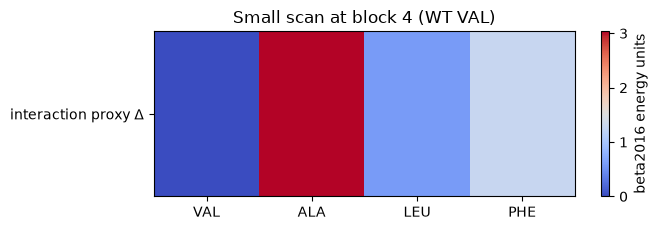

In [9]:
heatmap = scan_frame.set_index("variant")[["delta_proxy_vs_repacked_wt"]].T
fig, ax = plt.subplots(figsize=(7, 2.4))
image = ax.imshow(heatmap.to_numpy(), cmap="coolwarm", aspect="auto")
ax.set_xticks(range(len(heatmap.columns)), heatmap.columns)
ax.set_yticks([0], ["interaction proxy Δ"])
ax.set_title(f"Small scan at block {target_block} (WT {original_name3})")
fig.colorbar(image, ax=ax, label="beta2016 energy units")
plt.tight_layout()
plt.show()

**Expected observations.** Variants differ in both total score and their target-to-rest block-pair interaction. `shared_batch_seconds` is the wall time for the single packer call containing every row, not a per-variant time. The lowest number in this tiny, stochastic exercise is not a prediction of stability.

> **Energy-proxy warning.** `delta_proxy_vs_repacked_wt` is the change in weighted block-pair score assigned between the target block and all other blocks after independent repacking. It omits ensemble averaging, unfolded/reference states, adequate structural relaxation, and solvent/experimental calibration. It is neither a physical $\Delta\Delta G$ nor TMol's built-in mutation protocol.

In [10]:
best_variant = scan_frame.sort_values("total_score").iloc[0]["variant"]
variant_scores = scan_frame.set_index("variant")["total_score"].to_dict()
print("lowest total score in this tiny scan:", best_variant)
try:
    display(
        tmol.switchable_view(
            variant_poses,
            notes={
                variant: f"weighted score: {variant_scores[variant]:.3f}"
                for variant in variant_poses
            },
            width=720,
            height=420,
        )
    )
except ImportError as exc:
    print("Interactive mutation comparison unavailable:", exc)

lowest total score in this tiny scan: VAL


## Regional sequence design in one GPU-oriented batch

A mutation scan fixes one identity per pose. Design instead permits several identities at several positions and lets simulated annealing choose combinations jointly with side-chain conformers. Here four independent trajectories share one `PoseStack`; each can settle on a different sequence/conformation.

This is a small demonstration of TMol's lower-level task masks, not an equivalent of Rosetta resfiles, HBNet, FastDesign, or backbone design.

In [11]:
def restrict_regional_design(task, allowed_name3_by_block):
    """Keep the original identity elsewhere and allow a small design alphabet."""
    considered = task.per_block_considered_block_types
    keep = task.per_block_considered_block_types_is_orig.detach().clone()
    for pose_index in range(keep.shape[0]):
        for block_index, allowed_names in allowed_name3_by_block.items():
            considered_types = (
                considered[pose_index, block_index].detach().cpu().tolist()
            )
            allowed = torch.tensor(
                [
                    index >= 0
                    and task.pbt.active_block_types[index].name3 in allowed_names
                    for index in considered_types
                ],
                dtype=torch.bool,
                device=task.device,
            )
            if not torch.any(allowed):
                raise ValueError(f"No requested identities at block {block_index}")
            keep[pose_index, block_index] = allowed
    task.per_block_is_block_type_allowed = torch.logical_and(
        task.per_block_is_block_type_allowed, keep
    )
    return task


design_blocks = [4, 6]
design_alphabet = {
    block_index: {
        pose_stack.block_type(0, block_index).name3,
        "ALA",
        "LEU",
        "PHE",
    }
    for block_index in design_blocks
}
n_design_trajectories = 4
design_batch = PoseStackBuilder.from_poses(
    [pose_stack] * n_design_trajectories, device
)
design_task = PackerTask(design_batch, PackerPalette())
restrict_regional_design(design_task, design_alphabet)
add_standard_samplers(design_task)

torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.synchronize()
design_start = perf_counter()
designed_batch = pack_rotamers(design_batch, score_function, design_task)
if device.type == "cuda":
    torch.cuda.synchronize()
design_seconds = perf_counter() - design_start

design_rows = []
design_poses = {}
for pose_index in range(n_design_trajectories):
    designed_pose = designed_batch.split(pose_index)
    label = f"trajectory {pose_index + 1}"
    identities = [
        designed_pose.block_type(0, block_index).name3
        for block_index in design_blocks
    ]
    design_poses[label] = designed_pose
    design_rows.append(
        {
            "trajectory": pose_index + 1,
            "block_4_identity": identities[0],
            "block_6_identity": identities[1],
            "sequence_pair": "-".join(identities),
            "total_score": total_score(designed_pose),
            "shared_batch_seconds": design_seconds,
        }
    )

design_frame = pd.DataFrame(design_rows).sort_values("total_score")
show_table(design_frame)
try:
    display(
        tmol.switchable_view(
            design_poses,
            notes={
                f"trajectory {row['trajectory']}": row["sequence_pair"]
                for row in design_rows
            },
            width=720,
            height=420,
        )
    )
except ImportError as exc:
    print("Interactive design comparison unavailable:", exc)

## Rosetta comparison

Both systems separate a task describing allowed identities/conformers from the packing algorithm. Rosetta has mature `TaskOperation`, resfile, mover, and mutation-scan protocol layers. TMol exposes lower-level `PackerPalette`/`PackerTask` masks and GPU-oriented packer machinery, but no native point-mutation-scan protocol or Rosetta `ResidueSelector` equivalent.

For the complete Rosetta workflows, see [Optimizing Sidechains: The Packer](https://docs.rosettacommons.org/demos/latest/tutorials/Optimizing_Sidechains_The_Packer/Optimizing_Sidechains_The_Packer), [PyRosetta packing and regional relax](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.02-Packing-design-and-regional-relax.ipynb), [06.08 Point Mutation Scan](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.08-Point-Mutation-Scan.ipynb), and [16.01 distributed ddG/PSSM](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.01-PyData-ddG-pssm.ipynb).

## Limitations

- The restriction helpers use inspected task fields rather than stable high-level mutation/design APIs; revalidate them when packer internals change.
- The scan is batched at the `PoseStack`/packer level, but TMol does not provide a supported sequence-construction or scan protocol around it.
- Only one scan position and two design positions are sampled, with small alphabets, bounded repacking, and no backbone relaxation.
- The four design entries are stochastic annealing trajectories, not four statistically independent biological measurements.
- No unfolded-state reference, ensemble, or calibrated thermodynamic model is included.
- Absolute ranking can depend on random seed, sampler coverage, score-function choice, and structural context.
- TMol has no built-in mutation-scan or FastDesign protocol; production workflows must own task construction, scheduling, provenance, and validation.

## Exercises

1. Change the regional repacking mask and verify that disabled blocks retain their input coordinates.
2. Inspect which `name3` values the default palette considers at the target before choosing variants.
3. Repeat the tiny scan for two additional seeds and report mean and range without calling the result a $\Delta\Delta G$.
4. Add Cartesian minimization after each packed variant and state how that changes the computational experiment.
5. Sketch an external scheduler that shards positions across GPUs while preserving one result row per position, identity, seed, and score-function version.

## References

- [Rosetta Packer tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Optimizing_Sidechains_The_Packer/Optimizing_Sidechains_The_Packer)
- [PyRosetta 06.01 Side Chain Conformations and Dunbrack Energies](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.01-Side-Chain-Conformations-and-Dunbrack-Energies.ipynb)
- [PyRosetta 06.02 Packing and regional relax](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.02-Packing-design-and-regional-relax.ipynb)
- [PyRosetta 06.08 Point Mutation Scan](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.08-Point-Mutation-Scan.ipynb)
- [PyRosetta 16.01 distributed ddG/PSSM](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.01-PyData-ddG-pssm.ipynb)
- [TMol repository](https://github.com/uw-ipd/tmol)